In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv("/content/spam.csv", encoding="latin-1")

# Display dataset information
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Keep only the required columns
data = data[["v1", "v2"]]

# Rename columns
data.columns = ["label", "message"]

# Remove missing values and duplicate messages
data = data.dropna()
data = data.drop_duplicates()

# Convert labels: ham = 0, spam = 1
data["label_num"] = data["label"].map({"ham": 0, "spam": 1})

# Display cleaned dataset information
print("Cleaned Dataset Shape:", data.shape)
print("\nLabel Distribution:")
print(data["label"].value_counts())

data.head()

Cleaned Dataset Shape: (5169, 3)

Label Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [4]:
# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and target
X = data["message"]
y = data["label_num"]

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text messages into numerical features using TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",
    lowercase=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train the Naive Bayes model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Make predictions
predictions = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print("Email Spam Detection Model")
print("--------------------------")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    y_test,
    predictions,
    target_names=["Ham", "Spam"]
))

Email Spam Detection Model
--------------------------
Accuracy: 96.62%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [5]:
# Test the model with a custom message

message = input("Enter a message to check: ")

message_tfidf = vectorizer.transform([message])
prediction = model.predict(message_tfidf)[0]

if prediction == 1:
    print("Result: SPAM")
else:
    print("Result: NOT SPAM")

Enter a message to check: congratulations you won a free prize.click here to claim now.
Result: SPAM


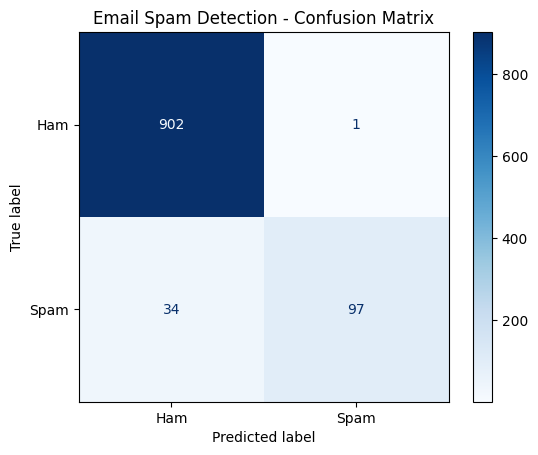

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)

plt.title("Email Spam Detection - Confusion Matrix")
plt.show()